### Bài 1: Tính Attention Score: Cho Q=[1,0,1], K=[[1,0,0],[0,1,0],[1,1,0]], V=[[1,2],[3,4],[5,6]]. Tính Attention(Q,K,V) theo công thức Scaled Dot-Product. (d_k=3)

In [6]:
import numpy as np

Q = np.array([1, 0, 1])
K = np.array([[1, 0, 0], [0, 1, 1], [1, 1, 0]])
V = np.array([[1, 2], [3, 4], [5, 6]])

d_k = 3

scores = Q @ K.T/np.sqrt(d_k)
attn = np.exp(scores)/np.sum(np.exp(scores), axis = -1, keepdims = True)

output = attn @ V

print(output)

[3. 4.]


### Bài 2: Python NumPy: Cài đặt hàm scaled_dot_product_attention(Q,K,V) bằng NumPy. Kiểm tra với ma trận 4x8 ngẫu nhiên. Vẽ heatmap attention weights bằng matplotlib.

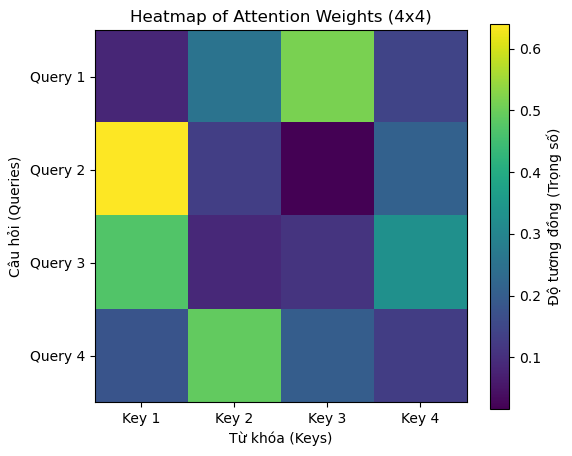

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def scaled_dot_product_attention(Q, K, V):
    # Lấy số chiều d_k từ ma trận Key (số cột của hàng cuối)
    d_k = K.shape[-1]
    
    # 1. Tính scores: Q nhân ma trận chuyển vị của K, rồi chia cho căn bậc hai của d_k
    scores = np.dot(Q, K.T) / np.sqrt(d_k)
    
    # 2. Tính Softmax để lấy ma trận trọng số (Attention Weights)
    # Trừ đi max để tránh lỗi tràn số khi tính hàm mũ (Trick lập trình thực tế)
    exp_scores = np.exp(scores - np.max(scores, axis=-1, keepdims=True))
    attention_weights = exp_scores / np.sum(exp_scores, axis=-1, keepdims=True)
    
    # 3. Nhân với ma trận Value
    output = np.dot(attention_weights, V)
    
    return output, attention_weights

# --- Thử nghiệm với ma trận 4x8 ngẫu nhiên ---
np.random.seed(42)  # Cố định dữ liệu ngẫu nhiên để không đổi khi chạy lại
Q_rand = np.random.randn(4, 8)  # 4 từ, mỗi từ có 8 chiều
K_rand = np.random.randn(4, 8)
V_rand = np.random.randn(4, 8)

# Chạy hàm
output, weights = scaled_dot_product_attention(Q_rand, K_rand, V_rand)

# --- Vẽ Heatmap hiển thị Attention Weights bằng Matplotlib ---
plt.figure(figsize=(6, 5))
plt.imshow(weights, cmap='viridis')  # Chọn bảng màu tương phản tốt
plt.colorbar(label='Độ tương đồng (Trọng số)')
plt.title("Heatmap of Attention Weights (4x4)")
plt.xlabel("Từ khóa (Keys)")
plt.ylabel("Câu hỏi (Queries)")
plt.xticks(range(4), [f'Key {i+1}' for i in range(4)])
plt.yticks(range(4), [f'Query {i+1}' for i in range(4)])
plt.show()

### Bài 3: Face Recognition: Dùng FaceNet (facenet-pytorch) nhận diện khuôn mặt từ webcam. So sánh embedding cosine similarity: sim(A,B) = A·B/(||A||·||B||). Ngưỡng nhận dạng: sim > 0.6

In [8]:
pip install opencv-python facenet-pytorch

  Using cached facenet_pytorch-2.6.0-py3-none-any.whl.metadata (12 kB)
INFO: pip is looking at multiple versions of facenet-pytorch to determine which version is compatible with other requirements. This could take a while.
  Using cached facenet_pytorch-2.5.3-py3-none-any.whl.metadata (13 kB)
  Using cached torchvision-0.27.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached torch-2.12.0-cp313-cp313-win_amd64.whl.metadata (31 kB)
Using cached facenet_pytorch-2.5.3-py3-none-any.whl (1.9 MB)
Using cached torchvision-0.27.0-cp313-cp313-win_amd64.whl (4.1 MB)
Using cached torch-2.12.0-cp313-cp313-win_amd64.whl (123.0 MB)

   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   --------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [9]:
import cv2
import torch
from facenet_pytorch import MTCNN, InceptionResnetV1
import numpy as np

# Khởi tạo mô hình phát hiện khuôn mặt (MTCNN) và trích xuất đặc trưng (FaceNet)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mtcnn = MTCNN(keep_all=False, device=device) # Lấy 1 khuôn mặt chính
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

def get_embedding(frame):
    """Hàm phát hiện khuôn mặt và chuyển về dạng vector vector đặc trưng (Embedding)"""
    # Chuyển ảnh từ dạng BGR (OpenCV) sang RGB
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    face = mtcnn(img_rgb)
    if face is not None:
        # Thêm 1 chiều kích thước và đưa qua mạng ResNet để lấy vector 512 chiều
        face_embedding = resnet(face.unsqueeze(0).to(device)).detach().cpu().numpy().flatten()
        return face_embedding
    return None

def cosine_similarity(A, B):
    """Tính toán độ tương đồng Cosine theo công thức đề bài yêu cầu"""
    dot_product = np.dot(A, B)
    norm_A = np.linalg.norm(A)
    norm_B = np.linalg.norm(B)
    return dot_product / (norm_A * norm_B)

# --- KHỞI CHẠY WEBCAM ---
cap = cv2.VideoCapture(0)
print("Bấm phím 's' để LƯU khuôn mặt gốc làm mẫu (Anchor Face).")
print("Bấm phím 'q' để THOÁT chương trình.")

anchor_embedding = None

while True:
    ret, frame = cap.read()
    if not ret:
        break
        
    # Lấy kích thước ảnh để hiển thị chữ lên màn hình
    h, w, _ = frame.shape
    
    # Thử lấy embedding của người đang đứng trước camera
    current_embedding = get_embedding(frame)
    
    if anchor_embedding is None:
        cv2.putText(frame, "Hay bam 's' de luu anh mau", (30, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 165, 255), 2)
    else:
        if current_embedding is not None:
            # So sánh độ trùng khớp giữa ảnh hiện tại và ảnh gốc ban đầu
            sim = cosine_similarity(anchor_embedding, current_embedding)
            
            # Kiểm tra ngưỡng nhận dạng > 0.6
            if sim > 0.6:
                text = f"XAC NHAN: Chinh chu (Sim: {sim:.2f})"
                color = (0, 255, 0) # Màu xanh lá
            else:
                text = f"CANH BAO: Nguoi la! (Sim: {sim:.2f})"
                color = (0, 0, 255) # Màu đỏ
                
            cv2.putText(frame, text, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        else:
            cv2.putText(frame, "Khong tim thay khuon mat", (30, 50), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
            
    cv2.imshow('Face Recognition Webcam', frame)
    
    key = cv2.waitKey(1) & 0xFF
    if key == ord('s') and current_embedding is not None:
        anchor_embedding = current_embedding
        print("Đã lưu mẫu khuôn mặt thành công!")
    elif key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


  0%|          | 0.00/107M [00:00<?, ?B/s]

Bấm phím 's' để LƯU khuôn mặt gốc làm mẫu (Anchor Face).
Bấm phím 'q' để THOÁT chương trình.


### Bài 4: ChatGPT API: Dùng openai Python SDK, gọi ChatCompletion.create() với temperature=0.7. So sánh kết quả với temperature=0 và temperature=1. Phân tích sự khác biệt output.

In [11]:
import os
from openai import OpenAI

# Khởi tạo client (Yêu cầu bạn phải có sẵn biến môi trường OPENAI_API_KEY)
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

prompt = "Hãy viết một câu danh ngôn ngắn gọn về sự kiên trì."

# Thử nghiệm với 3 mức độ Temperature khác nhau
for temp in [0.0, 0.7, 1.0]:
    response = client.chat.completions.create(
        model="gpt-4o-mini", # hoặc gpt-4
        messages=[{"role": "user", "content": prompt}],
        temperature=temp
    )
    print(f"=== Kết quả với Temperature = {temp} ===")
    print(response.choices[0].message.content.strip())
    print("-" * 40)


ModuleNotFoundError: No module named 'openai'